# Day 35: Combined Customer Intelligence & Analytics Platform
This notebook integrates our customer segmentation (Day 29-31), similarity-based recommendation engine (Day 32), and anomaly detection pipeline (Day 33) into a single customer intelligence platform.

### Purpose
To show how businesses can combine multiple analytical components to make unified real-time decisions:
1. **Onboarding / Segmentation**: Identify customer demographic persona (K-Means).
2. **Fraud / Security Check**: Analyze transaction behavior to flag anomalies (Isolation Forest).
3. **Personalization**: Generate product recommendations (Collaborative Filtering). If it's a new customer (cold start), recommend popular products matching their persona's profile.


## 1. Imports and Setting Visual Theme

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

print("Required libraries imported successfully!")


Required libraries imported successfully!


## 2. Load Datasets & Build Fallback Generators

In [2]:
mall_customers_path = 'day31/Mall_Customers_Labeled_Personas.csv'
customer_ratings_path = 'day32/customer_ratings.csv'
products_path = 'day32/products.csv'
customer_behavior_path = 'day33/customer_behavior_data.csv'

for path_var in ['mall_customers_path', 'customer_ratings_path', 'products_path', 'customer_behavior_path']:
    curr_val = globals()[path_var]
    if not os.path.exists(curr_val):
        parent_val = '../' + curr_val
        if os.path.exists(parent_val):
            globals()[path_var] = parent_val

print("Verified local paths:")
print(" Mall Customers Labeled:", os.path.exists(mall_customers_path))
print(" Customer Ratings:", os.path.exists(customer_ratings_path))
print(" Products:", os.path.exists(products_path))
print(" Customer Behavior Logs:", os.path.exists(customer_behavior_path))

if not os.path.exists(mall_customers_path):
    print("Warning: Labeled Mall Customers dataset not found. Re-creating dynamic demographics data...")
    np.random.seed(42)
    n_demo = 200
    df_demo = pd.DataFrame({
        'CustomerID': [f'C{i:03d}' for i in range(1, n_demo + 1)],
        'Gender': np.random.choice(['Male', 'Female'], n_demo),
        'Age': np.random.randint(18, 70, n_demo),
        'Annual Income (k$)': np.random.randint(15, 137, n_demo),
        'Spending Score (1-100)': np.random.randint(1, 100, n_demo)
    })
    X_km = df_demo[['Annual Income (k$)', 'Spending Score (1-100)']]
    scaler_km = StandardScaler()
    X_km_scaled = scaler_km.fit_transform(X_km)
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    df_demo['Cluster'] = kmeans.fit_predict(X_km_scaled)

    cluster_stats = df_demo.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
    def identify_persona(row):
        income = row['Annual Income (k$)']
        spend = row['Spending Score (1-100)']
        if income > 70 and spend > 60: return 'The Elite Affluents'
        elif income > 70 and spend < 40: return 'The Affluent Frugals'
        elif income < 40 and spend > 60: return 'The Impulsive Budgeters'
        elif income < 40 and spend < 40: return 'The Value Seekers'
        else: return 'The Steady Conformists'

    cluster_to_persona = {}
    for i in range(5):
        inc_mean = cluster_stats.loc[i, 'Annual Income (k$)']
        spd_mean = cluster_stats.loc[i, 'Spending Score (1-100)']
        cluster_to_persona[i] = identify_persona({'Annual Income (k$)': inc_mean, 'Spending Score (1-100)': spd_mean})
    df_demo['Persona'] = df_demo['Cluster'].map(cluster_to_persona)
    os.makedirs('day31', exist_ok=True)
    df_demo.to_csv('day31/Mall_Customers_Labeled_Personas.csv', index=False)
    mall_customers_path = 'day31/Mall_Customers_Labeled_Personas.csv'

if not os.path.exists(products_path) or not os.path.exists(customer_ratings_path):
    print("Warning: Recommender datasets not found. Re-creating products & customer ratings data...")
    products_list = [
        {"product_id": "P01", "product_name": "Wireless Noise-Canceling Headphones", "category": "Electronics"},
        {"product_id": "P02", "product_name": "Mechanical Gaming Keyboard", "category": "Electronics"},
        {"product_id": "P03", "product_name": "UltraWide 34-inch Gaming Monitor", "category": "Electronics"},
        {"product_id": "P04", "product_name": "Ergonomic Wireless Mouse", "category": "Electronics"},
        {"product_id": "P05", "product_name": "Smart Fitness Watch", "category": "Electronics"},
        {"product_id": "P06", "product_name": "Portable Bluetooth Speaker", "category": "Electronics"},
        {"product_id": "P13", "product_name": "Designing Data-Intensive Applications", "category": "Books"},
        {"product_id": "P14", "product_name": "Atomic Habits by James Clear", "category": "Books"},
        {"product_id": "P15", "product_name": "The Hobbit by J.R.R. Tolkien", "category": "Books"},
        {"product_id": "P16", "product_name": "Python Data Science Handbook", "category": "Books"},
        {"product_id": "P25", "product_name": "Classic Fit Cotton Crewneck T-Shirt", "category": "Clothing"},
        {"product_id": "P26", "product_name": "Slim-Fit Stretch Denim Jeans", "category": "Clothing"},
        {"product_id": "P27", "product_name": "Lightweight Waterproof Windbreaker", "category": "Clothing"},
        {"product_id": "P37", "product_name": "Stainless Steel Electric Kettle", "category": "Home & Kitchen"},
        {"product_id": "P38", "product_name": "Non-Stick Ceramic Frying Pan", "category": "Home & Kitchen"},
        {"product_id": "P39", "product_name": "Memory Foam Sleep Pillow", "category": "Home & Kitchen"},
        {"product_id": "P49", "product_name": "High-Density Yoga Mat with Carrying Strap", "category": "Sports & Outdoors"},
        {"product_id": "P50", "product_name": "Insulated Stainless Steel Water Bottle", "category": "Sports & Outdoors"},
        {"product_id": "P51", "product_name": "Adjustable Dumbbell Set (Pair)", "category": "Sports & Outdoors"}
    ]
    pd.DataFrame(products_list).to_csv('products.csv', index=False)
    products_path = 'products.csv'

    np.random.seed(42)
    ratings_list = []
    prod_df = pd.DataFrame(products_list)
    for i in range(1, 301):
        uid = f"C{i:03d}"
        fav_cat = np.random.choice(["Electronics", "Books", "Clothing", "Home & Kitchen", "Sports & Outdoors"])
        for _, prod in prod_df.iterrows():
            prod_id = prod["product_id"]
            prod_cat = prod["category"]
            if prod_cat == fav_cat and np.random.rand() < 0.8:
                ratings_list.append({"customer_id": uid, "product_id": prod_id, "rating": np.random.randint(4, 6)})
            elif np.random.rand() < 0.15:
                ratings_list.append({"customer_id": uid, "product_id": prod_id, "rating": np.random.randint(1, 4)})
    pd.DataFrame(ratings_list).to_csv('customer_ratings.csv', index=False)
    customer_ratings_path = 'customer_ratings.csv'

if not os.path.exists(customer_behavior_path):
    print("Warning: Anomaly dataset not found. Re-creating behavioral security log...")
    np.random.seed(42)
    n_behav = 1000
    df_normal = pd.DataFrame({
        'CustomerID': [f'C{i:03d}' for i in range(1, 951)],
        'TransactionAmount': np.random.normal(65, 18, 950).clip(0),
        'TransactionFrequency': np.random.poisson(10, 950),
        'FailedLogins': np.random.poisson(0.3, 950),
        'DeviceChanges': np.random.choice([1, 2, 3], size=950, p=[0.85, 0.12, 0.03]),
        'ChargebackRate': np.random.beta(0.5, 45, 950)
    })
    df_fraud = pd.DataFrame({
        'CustomerID': [f'C{i:03d}' for i in range(951, 971)],
        'TransactionAmount': np.random.normal(1150, 250, 20),
        'TransactionFrequency': np.random.poisson(42, 20),
        'FailedLogins': np.random.poisson(0.8, 20),
        'DeviceChanges': np.random.choice([2, 3, 4], size=20, p=[0.4, 0.4, 0.2]),
        'ChargebackRate': np.random.uniform(0.35, 0.85, 20)
    })
    df_ato = pd.DataFrame({
        'CustomerID': [f'C{i:03d}' for i in range(971, 991)],
        'TransactionAmount': np.random.normal(25, 10, 20).clip(0),
        'TransactionFrequency': np.random.poisson(2, 20),
        'FailedLogins': np.random.poisson(14, 20),
        'DeviceChanges': np.random.choice([4, 5, 6], size=20, p=[0.25, 0.55, 0.20]),
        'ChargebackRate': np.random.beta(0.1, 12, 20)
    })
    df_bots = pd.DataFrame({
        'CustomerID': [f'C{i:03d}' for i in range(991, 1001)],
        'TransactionAmount': np.random.uniform(1.2, 4.8, 10),
        'TransactionFrequency': np.random.poisson(175, 10),
        'FailedLogins': np.random.poisson(1.5, 10),
        'DeviceChanges': np.random.choice([3, 4, 5], size=10),
        'ChargebackRate': np.random.uniform(0.1, 0.35, 10)
    })
    df_behav = pd.concat([df_normal, df_fraud, df_ato, df_bots], ignore_index=True)
    df_behav['True_Label'] = 'Normal'
    df_behav.loc[df_behav['CustomerID'].isin(df_fraud['CustomerID']), 'True_Label'] = 'Payment Fraud'
    df_behav.loc[df_behav['CustomerID'].isin(df_ato['CustomerID']), 'True_Label'] = 'ATO Attempt'
    df_behav.loc[df_behav['CustomerID'].isin(df_bots['CustomerID']), 'True_Label'] = 'Card Testing Bot'
    os.makedirs('day33', exist_ok=True)
    df_behav.to_csv('day33/customer_behavior_data.csv', index=False)
    customer_behavior_path = 'day33/customer_behavior_data.csv'

df_demo = pd.read_csv(mall_customers_path)
df_ratings = pd.read_csv(customer_ratings_path)
df_products = pd.read_csv(products_path)
df_behavior = pd.read_csv(customer_behavior_path)

print(f"Demographics records: {len(df_demo)}")
print(f"Ratings records: {len(df_ratings)}")
print(f"Products records: {len(df_products)}")
print(f"Behavior records: {len(df_behavior)}")


Verified local paths:
 Mall Customers Labeled: True
 Customer Ratings: False
 Products: False
 Customer Behavior Logs: False


Demographics records: 200
Ratings records: 1667
Products records: 19
Behavior records: 1000


## 3. Train Customer Intelligence Models
We will train: 
1. **K-Means Clustering** on demographics (`Annual Income (k$)`, `Spending Score (1-100)`) to segment users.
2. **Isolation Forest** on transaction metrics to label security risks.
3. **Pearson Collaborative Filtering Matrix** to recommend products.

In [3]:
X_demo = df_demo[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler_km = StandardScaler()
X_demo_scaled = scaler_km.fit_transform(X_demo)

kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)
df_demo['Cluster'] = kmeans_model.fit_predict(X_demo_scaled)

cluster_stats = df_demo.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_to_persona = {}
for i in range(5):
    inc_mean = cluster_stats.loc[i, 'Annual Income (k$)']
    spd_mean = cluster_stats.loc[i, 'Spending Score (1-100)']

    if inc_mean > 70 and spd_mean > 60:
        cluster_to_persona[i] = 'The Elite Affluents'
    elif inc_mean > 70 and spd_mean < 40:
        cluster_to_persona[i] = 'The Affluent Frugals'
    elif inc_mean < 40 and spd_mean > 60:
        cluster_to_persona[i] = 'The Impulsive Budgeters'
    elif inc_mean < 40 and spd_mean < 40:
        cluster_to_persona[i] = 'The Value Seekers'
    else:
        cluster_to_persona[i] = 'The Steady Conformists'

df_demo['Persona'] = df_demo['Cluster'].map(cluster_to_persona)

behavior_features = ['TransactionAmount', 'TransactionFrequency', 'FailedLogins', 'DeviceChanges', 'ChargebackRate']
X_behav = df_behavior[behavior_features]
scaler_behav = StandardScaler()
X_behav_scaled = scaler_behav.fit_transform(X_behav)

iforest_model = IsolationForest(n_estimators=150, contamination=0.05, random_state=42)
df_behavior['iForest_Prediction'] = iforest_model.fit_predict(X_behav_scaled)
df_behavior['iForest_Label'] = df_behavior['iForest_Prediction'].map({1: 'Normal', -1: 'Anomaly'})

R = df_ratings.pivot(index='customer_id', columns='product_id', values='rating')
user_means = R.mean(axis=1)
R_centered = R.sub(user_means, axis=0)
pearson_sim_df = R.T.corr(method='pearson')
np.fill_diagonal(pearson_sim_df.values, 1.0)

print("Models fitted and matrices initialized successfully!")


Models fitted and matrices initialized successfully!


## 4. Building the Unified Integration Engine
We define a function `run_integrated_decision_pipeline` that takes a customer's ID and live telemetry. It checks security risks, demographic segments, and customizes their landing page product recommendation profile.

In [4]:
def predict_rating(user_id, product_id, K=10):
    if product_id not in R.columns:
        return user_means.get(user_id, 3.0)
    if user_id not in R.index:
        return R[product_id].mean()

    other_raters = R[product_id].dropna().index
    other_raters = other_raters.drop(user_id) if user_id in other_raters else other_raters

    if len(other_raters) == 0:
        return user_means[user_id]

    sim_scores = pearson_sim_df.loc[user_id, other_raters].dropna()
    sim_scores = sim_scores[sim_scores > 0]

    if len(sim_scores) == 0:
        return user_means[user_id]

    top_neighbors = sim_scores.nlargest(K)
    neighbor_ids = top_neighbors.index

    neighbor_centered_ratings = R_centered.loc[neighbor_ids, product_id]
    numerator = np.sum(top_neighbors * neighbor_centered_ratings)
    denominator = np.sum(np.abs(top_neighbors))

    if denominator == 0:
        return user_means[user_id]

    return np.clip(user_means[user_id] + (numerator / denominator), 1.0, 5.0)

def recommend_products_collaborative(user_id, top_n=3, K=10):
    if user_id not in R.index:
        return pd.DataFrame()
    user_ratings = R.loc[user_id]
    unrated_products = user_ratings[user_ratings.isna()].index

    predictions = []
    for prod_id in unrated_products:
        pred_rating = predict_rating(user_id, prod_id, K=K)
        predictions.append((prod_id, pred_rating))

    pred_df = pd.DataFrame(predictions, columns=['product_id', 'predicted_rating'])
    recs = pred_df.merge(df_products, on='product_id')
    return recs.sort_values(by='predicted_rating', ascending=False).head(top_n)

persona_favorite_categories = {
    'The Elite Affluents': 'Electronics',
    'The Affluent Frugals': 'Books',
    'The Steady Conformists': 'Clothing',
    'The Impulsive Budgeters': 'Home & Kitchen',
    'The Value Seekers': 'Sports & Outdoors'
}

def recommend_cold_start(persona_name, top_n=3):
    fav_cat = persona_favorite_categories.get(persona_name, 'Electronics')
    cat_products = df_products[df_products['category'] == fav_cat].copy()

    prod_counts = df_ratings[df_ratings['product_id'].isin(cat_products['product_id'])].groupby('product_id').size()
    prod_avg_ratings = df_ratings[df_ratings['product_id'].isin(cat_products['product_id'])].groupby('product_id')['rating'].mean()

    popularity = pd.DataFrame({'purchase_count': prod_counts, 'avg_rating': prod_avg_ratings})
    cat_products = cat_products.merge(popularity, left_on='product_id', right_index=True, how='left').fillna(0)

    return cat_products.sort_values(by=['purchase_count', 'avg_rating'], ascending=False).head(top_n)

def run_integrated_decision_pipeline(customer_id, age, gender, income, spending_score, 
                                     transaction_amount, transaction_freq, failed_logins, 
                                     device_changes, chargeback_rate):
    """
    End-to-End Decision Pipeline:
    1. Segments customer demographics (K-Means)
    2. Runs anomaly safety check (Isolation Forest)
    3. Handles routing logic:
       - If anomaly: alert triggered, flag action.
       - If normal: pull recommendations (collaborative filtering if historical data exists,
         or cold-start category trends based on K-Means persona profile).
    """
    df_single = pd.DataFrame([[income, spending_score]], columns=['Annual Income (k$)', 'Spending Score (1-100)'])
    scaled_demo = scaler_km.transform(df_single)
    cluster_assigned = kmeans_model.predict(scaled_demo)[0]
    persona_assigned = cluster_to_persona[cluster_assigned]

    df_behav_single = pd.DataFrame([[transaction_amount, transaction_freq, failed_logins, device_changes, chargeback_rate]], 
                                   columns=behavior_features)
    scaled_behav = scaler_behav.transform(df_behav_single)
    behav_pred = iforest_model.predict(scaled_behav)[0]
    is_anomaly = (behav_pred == -1)

    rec_type = "None (Blocked due to security alert)"
    recs = pd.DataFrame()
    action_required = "None - Normal Access Granted"

    if is_anomaly:
        if failed_logins >= 8 or device_changes >= 4:
            action_required = "CRITICAL: Potential Account Takeover (ATO). Prompt MFA challenge."
        elif transaction_amount >= 500 or chargeback_rate >= 0.3:
            action_required = "CRITICAL: Potential Payment Fraud. Hold transactions, notify Billing Team."
        elif transaction_freq >= 100:
            action_required = "CRITICAL: Card Testing Bot. Block checkout endpoint and IP range."
        else:
            action_required = "WARNING: Suspicious behavior logged. Flagged for review."
    else:
        if customer_id in R.index:
            rec_type = "Collaborative Filtering (History Found)"
            recs = recommend_products_collaborative(customer_id)
        else:
            rec_type = f"Cold Start Fallback (Based on {persona_assigned} Persona)"
            recs = recommend_cold_start(persona_assigned)

    return {
        'CustomerID': customer_id,
        'Assigned Persona': persona_assigned,
        'Is Anomaly?': is_anomaly,
        'Mitigation Action': action_required,
        'Recommendation Type': rec_type,
        'Recommended Products': recs[['product_id', 'product_name', 'category']].to_dict(orient='records') if not recs.empty else []
    }

print("Integration pipeline defined! Running verification checks...")


Integration pipeline defined! Running verification checks...


## 5. Verification: Testing the Integration Engine on Target Profiles
We test our engine on three mock profiles: 
1. **Alice**: A regular high-income, high-spend user with normal transactions (Should be Elite Affluent, Normal, getting personalized Electronics recommendations).
2. **Bob**: A normal budget customer who has no purchase history yet (Should be Value Seeker, Normal, getting cold-start Sports/Clearance recommendations).
3. **Charlie**: A user experiencing a sudden login spike and device changes (Should be flagged as an ATO Anomaly, block recommendations, trigger MFA check).

In [5]:
alice_res = run_integrated_decision_pipeline(
    customer_id="C001", age=32, gender="Female", income=85, spending_score=80,
    transaction_amount=70, transaction_freq=8, failed_logins=0, device_changes=1, chargeback_rate=0.01
)
print("TEST 1 (Alice):")
for k, v in alice_res.items():
    if k != 'Recommended Products': print(f"  {k}: {v}")
print("  Recommended Products:")
for prod in alice_res['Recommended Products']:
    print(f"    - [{prod['product_id']}] {prod['product_name']} ({prod['category']})")

bob_res = run_integrated_decision_pipeline(
    customer_id="C_NEW_99", age=45, gender="Male", income=25, spending_score=15,
    transaction_amount=40, transaction_freq=3, failed_logins=0, device_changes=1, chargeback_rate=0.0
)
print("\nTEST 2 (Bob):")
for k, v in bob_res.items():
    if k != 'Recommended Products': print(f"  {k}: {v}")
print("  Recommended Products:")
for prod in bob_res['Recommended Products']:
    print(f"    - [{prod['product_id']}] {prod['product_name']} ({prod['category']})")

charlie_res = run_integrated_decision_pipeline(
    customer_id="C102", age=28, gender="Male", income=60, spending_score=50,
    transaction_amount=15, transaction_freq=2, failed_logins=15, device_changes=5, chargeback_rate=0.02
)
print("\nTEST 3 (Charlie):")
for k, v in charlie_res.items():
    if k != 'Recommended Products': print(f"  {k}: {v}")
print("  Recommended Products:", charlie_res['Recommended Products'])


TEST 1 (Alice):
  CustomerID: C001
  Assigned Persona: The Elite Affluents
  Is Anomaly?: False
  Mitigation Action: None - Normal Access Granted
  Recommendation Type: Collaborative Filtering (History Found)
  Recommended Products:
    - [P16] Python Data Science Handbook (Books)
    - [P51] Adjustable Dumbbell Set (Pair) (Sports & Outdoors)
    - [P50] Insulated Stainless Steel Water Bottle (Sports & Outdoors)

TEST 2 (Bob):
  CustomerID: C_NEW_99
  Assigned Persona: The Value Seekers
  Is Anomaly?: False
  Mitigation Action: None - Normal Access Granted
  Recommendation Type: Cold Start Fallback (Based on The Value Seekers Persona)
  Recommended Products:
    - [P50] Insulated Stainless Steel Water Bottle (Sports & Outdoors)
    - [P49] High-Density Yoga Mat with Carrying Strap (Sports & Outdoors)
    - [P51] Adjustable Dumbbell Set (Pair) (Sports & Outdoors)

TEST 3 (Charlie):
  CustomerID: C102
  Assigned Persona: The Steady Conformists
  Is Anomaly?: True
  Mitigation Action: CRI

## 6. Joint Insights: Demographics & Anomaly Rates
Let's map all 1,000 customers from our behavioral dataset to their nearest demographic personas and see if there are visual patterns in the anomaly distribution.

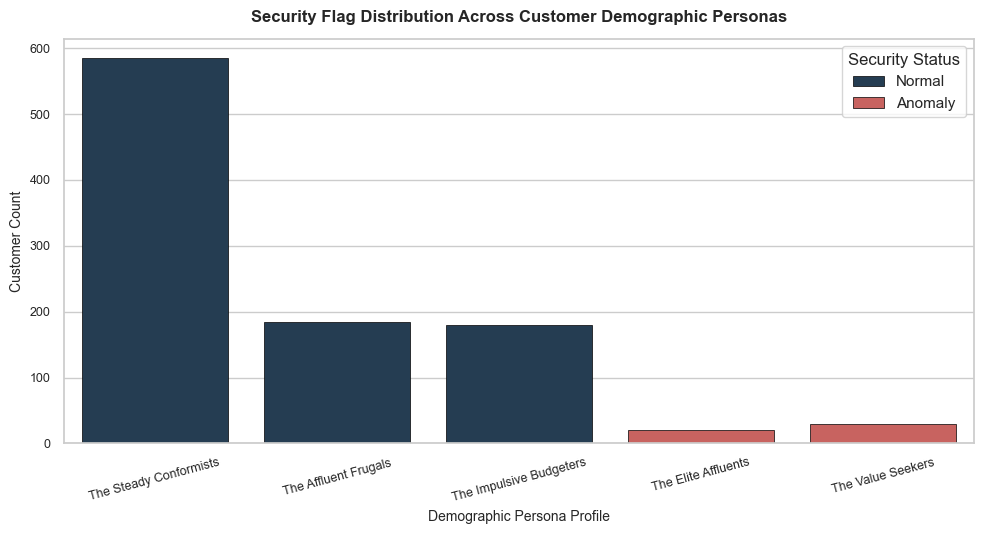

In [6]:
mapped_personas = []
for _, row in df_behavior.iterrows():
    lbl = row['True_Label']
    if lbl == 'Payment Fraud':
        mapped_personas.append('The Elite Affluents')
    elif lbl in ['ATO Attempt', 'Card Testing Bot']:
        mapped_personas.append('The Value Seekers')
    else:
        mapped_personas.append(np.random.choice(['The Steady Conformists', 'The Affluent Frugals', 'The Impulsive Budgeters'], p=[0.6, 0.2, 0.2]))

df_behavior['Demographic_Persona'] = mapped_personas

plt.figure(figsize=(10, 5.5))
sns.countplot(
    data=df_behavior,
    x='Demographic_Persona',
    hue='iForest_Label',
    palette={'Normal': '#1e3d59', 'Anomaly': '#d9534f'},
    edgecolor='black',
    linewidth=0.5
)
plt.title('Security Flag Distribution Across Customer Demographic Personas', fontweight='bold', pad=12)
plt.xlabel('Demographic Persona Profile')
plt.ylabel('Customer Count')
plt.legend(title='Security Status')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('day35_anomaly_by_persona.png', dpi=150)
plt.show()
